# 05 — Hoisting the shared per-patch work

**Did each implementation factor the patch-level climate work out of the
per-organism loop?**

In the ForeverTree spec `%T` and `%P` depend only on (patch, timestep), so they
are identical for all 10 trees on a patch — only the stochastic term varies.
The available optimisation is to compute that shared work once per patch-step.
The expert references do this (Josh: a patch-scope `conditionImpact` the trees
read via `here.`; Mesa: a `(cell, timestep)` cache under the climate accessor);
the AI-authored Mesa reference does not.

Source: [`analysis/hoist.csv`](hoist.csv), rolled up from the per-cell
`scorer.hoist.json` records (schema `hoist-v2`) by `pixi run hoist-judge`.
Rubric: [`prompts/HOIST_JUDGE.md`](../prompts/HOIST_JUDGE.md).

| answer | meaning |
|---|---|
| `yes` | lookup **and** both response curves computed once per patch-step |
| `partial` | an attempt that got part-way — nearly always the lookup hoisted, curves still per-tree |
| `no` | every organism does its own lookup and curve evaluation |
| `n-a` | no per-organism growth loop in the source to judge |

`residual` records what patch-invariant work the live path still repeats per
organism, *whatever* the verdict — so the `yes` threshold (which forgives a
trailing multiply over already-hoisted scalars) is visible rather than baked in.


In [1]:
options(repr.plot.width = 8, repr.plot.height = 3.2, repr.plot.res = 120)
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(tidyr)
  library(forcats)
  library(ggplot2)
  library(scales)
})

# Lato (bundled in analysis/fonts/, OFL) — same wiring as 01_analysis.ipynb.
library(showtext)
font_add("Lato",
         regular    = "fonts/Lato-Regular.ttf",
         bold       = "fonts/Lato-Bold.ttf",
         italic     = "fonts/Lato-Italic.ttf",
         bolditalic = "fonts/Lato-BoldItalic.ttf")
showtext_auto()
showtext_opts(dpi = 300)
options(repr.plot.res = 300)
update_geom_defaults("text", list(family = "Lato"))

# --- Scope, identical to 01_analysis.ipynb / 03_manuscript_claims.ipynb. ---
MODEL_ORDER  <- c("sonnet", "gemma", "kimi", "minimax", "mistral",
                  "glm", "qwen", "nemotron", "deepseek")
TARGET_ORDER <- c("mesa", "josh", "josh-mcp")
BATCH_FILTER <- c("headline-stage1-20260601", "headline-rerep-202606020525",
                  "headline-rerep-202606021512", "fill-*")
ANSWER_ORDER <- c("yes", "partial", "no", "n-a")

# Ordinal ramp for no -> partial -> yes in one hue, light->dark, plus a neutral
# for the off-scale n-a. Steps sit in the validated ordinal band for a light
# surface; nothing lighter holds against the panel.
ANSWER_COLORS <- c("yes" = "#184f95", "partial" = "#3987e5",
                   "no" = "#86b6ef", "n-a" = "#9a9a97")

theme_hoist <- function(base = 10) {
  theme_minimal(base_size = base, base_family = "Lato") +
    theme(panel.grid.minor = element_blank(),
          panel.grid.major.y = element_blank(),
          strip.text = element_text(face = "bold"),
          legend.position = "top")
}

OUT_DIR <- "figures"
dir.create(OUT_DIR, showWarnings = FALSE)

Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
# cwd-robust: notebook runs from analysis/ (pixi run lab) or the repo root.
HOIST <- if (file.exists("hoist.csv")) "hoist.csv" else "analysis/hoist.csv"
AGG   <- if (file.exists("aggregated.csv")) "aggregated.csv" else "analysis/aggregated.csv"

.pat <- paste0("^(", paste(gsub("\\*", ".*", BATCH_FILTER), collapse = "|"), ")$")

# aggregated.csv carries the canonical outcome columns; hoist.csv the answers.
agg <- read_csv(AGG, show_col_types = FALSE) %>%
  filter(grepl(.pat, batch_tag), model %in% MODEL_ORDER, target %in% TARGET_ORDER) %>%
  mutate(passed = tolower(as.character(substantive_conformance)) == "true" &
                  tolower(as.character(did_run)) == "true") %>%
  select(run_id, passed)

hoist <- read_csv(HOIST, show_col_types = FALSE) %>%
  filter(grepl(.pat, batch_tag), model %in% MODEL_ORDER, target %in% TARGET_ORDER) %>%
  mutate(model  = factor(model,  levels = MODEL_ORDER),
         target = factor(target, levels = TARGET_ORDER),
         answer = factor(hoist_answer, levels = ANSWER_ORDER)) %>%
  left_join(agg, by = "run_id")

errs <- sum(hoist$hoist_parse_error != "" & !is.na(hoist$hoist_parse_error))
cat(sprintf("%d cells in scope | %d parse error(s) | judge: %s\n",
            nrow(hoist), errs, paste(unique(hoist$judge_model_id), collapse = ", ")))
cat(sprintf("batches: %s\n", paste(sort(unique(hoist$batch_tag)), collapse = ", ")))
stopifnot(!any(is.na(hoist$answer)))

220 cells in scope | 0 parse error(s) | judge: openai/gpt-5.1-codex


batches: fill-202606032041, headline-rerep-202606020525, headline-rerep-202606021512, headline-stage1-20260601


## Headline


In [3]:
overall <- hoist %>%
  count(target, answer, .drop = FALSE) %>%
  group_by(target) %>%
  mutate(share = n / sum(n)) %>%
  ungroup()

overall %>%
  select(target, answer, n, share) %>%
  mutate(share = percent(share, accuracy = 1)) %>%
  pivot_wider(names_from = answer, values_from = c(n, share),
              names_vary = "slowest") %>%
  print(width = 200)

# 'attempted' = yes + partial, over the cells that had something to judge.
hoist %>%
  filter(answer != "n-a") %>%
  group_by(target) %>%
  summarise(n = n(),
            attempted = sum(answer %in% c("yes", "partial")),
            fully     = sum(answer == "yes"),
            .groups = "drop") %>%
  mutate(attempted_pct = percent(attempted / n, accuracy = 1),
         fully_pct     = percent(fully / n, accuracy = 1)) %>%
  print()

# A tibble: 3 × 9
  target   n_yes share_yes n_partial share_partial  n_no share_no `n_n-a`
  <fct>    <int> <chr>         <int> <chr>         <int> <chr>      <int>
1 mesa         5 7%               47 64%              12 16%           10
2 josh         3 4%               41 55%              20 27%           10
3 josh-mcp     6 8%               35 49%              19 26%           12
  `share_n-a`
  <chr>      
1 14%        
2 14%        
3 17%        


# A tibble: 3 × 6
  target       n attempted fully attempted_pct fully_pct
  <fct>    <int>     <int> <int> <chr>         <chr>    
1 mesa        64        52     5 81%           8%       
2 josh        64        44     3 69%           5%       
3 josh-mcp    60        41     6 68%           10%      


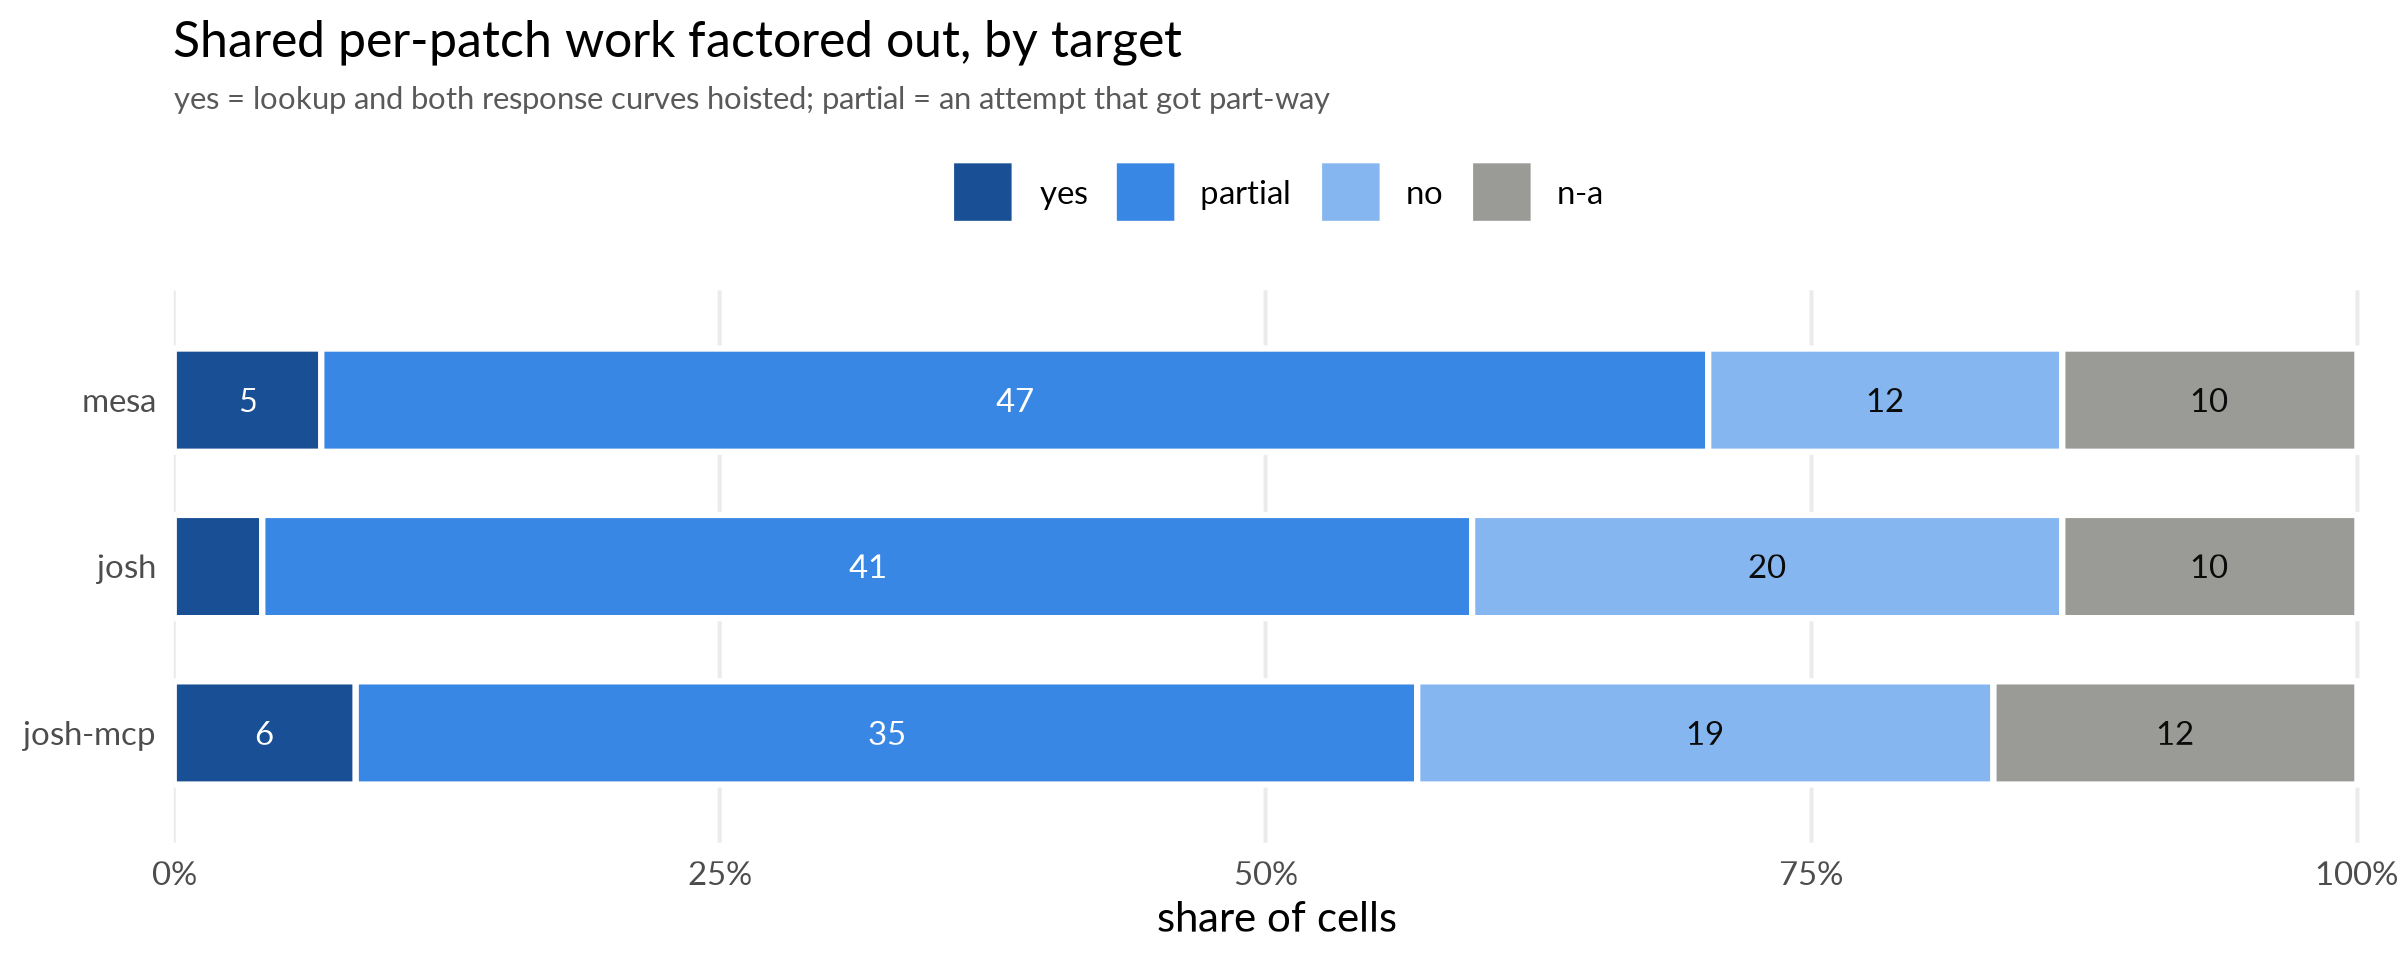

In [4]:
# 100% stacked composition by target. Geometry is computed explicitly rather
# than via position_stack: geom_col orders segments by the fill factor while
# geom_text's stacking follows data-row order, and the two silently disagree,
# putting labels on the wrong segments.
bars <- overall %>%
  arrange(target, answer) %>%
  group_by(target) %>%
  mutate(xmax = cumsum(share), xmin = xmax - share, xmid = xmax - share / 2) %>%
  ungroup() %>%
  mutate(yi   = as.integer(factor(target, levels = rev(TARGET_ORDER))),
         ymin = yi - 0.31, ymax = yi + 0.31)

p_target <- ggplot(bars) +
  geom_rect(aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = answer),
            colour = "white", linewidth = 0.7) +
  geom_text(data = filter(bars, share > 0.06),
            aes(x = xmid, y = yi, label = n,
                colour = answer %in% c("yes", "partial")),
            size = 2.8, show.legend = FALSE) +
  scale_fill_manual(values = ANSWER_COLORS, name = NULL, drop = FALSE) +
  scale_colour_manual(values = c(`TRUE` = "white", `FALSE` = "#0b0b0b"), guide = "none") +
  scale_x_continuous(labels = percent_format(accuracy = 1),
                     expand = expansion(mult = c(0, 0.01))) +
  scale_y_continuous(breaks = seq_along(TARGET_ORDER), labels = rev(TARGET_ORDER),
                     expand = expansion(add = 0.35)) +
  labs(title = "Shared per-patch work factored out, by target",
       subtitle = "yes = lookup and both response curves hoisted; partial = an attempt that got part-way",
       x = "share of cells", y = NULL) +
  theme_hoist() +
  theme(plot.subtitle = element_text(colour = "grey35", size = 7.5))

p_target
ggsave(file.path(OUT_DIR, "hoist_by_target.png"), p_target,
       width = 8, height = 3, dpi = 300, bg = "white")
ggsave(file.path(OUT_DIR, "hoist_by_target.pdf"), p_target, width = 8, height = 3)

## By model × target


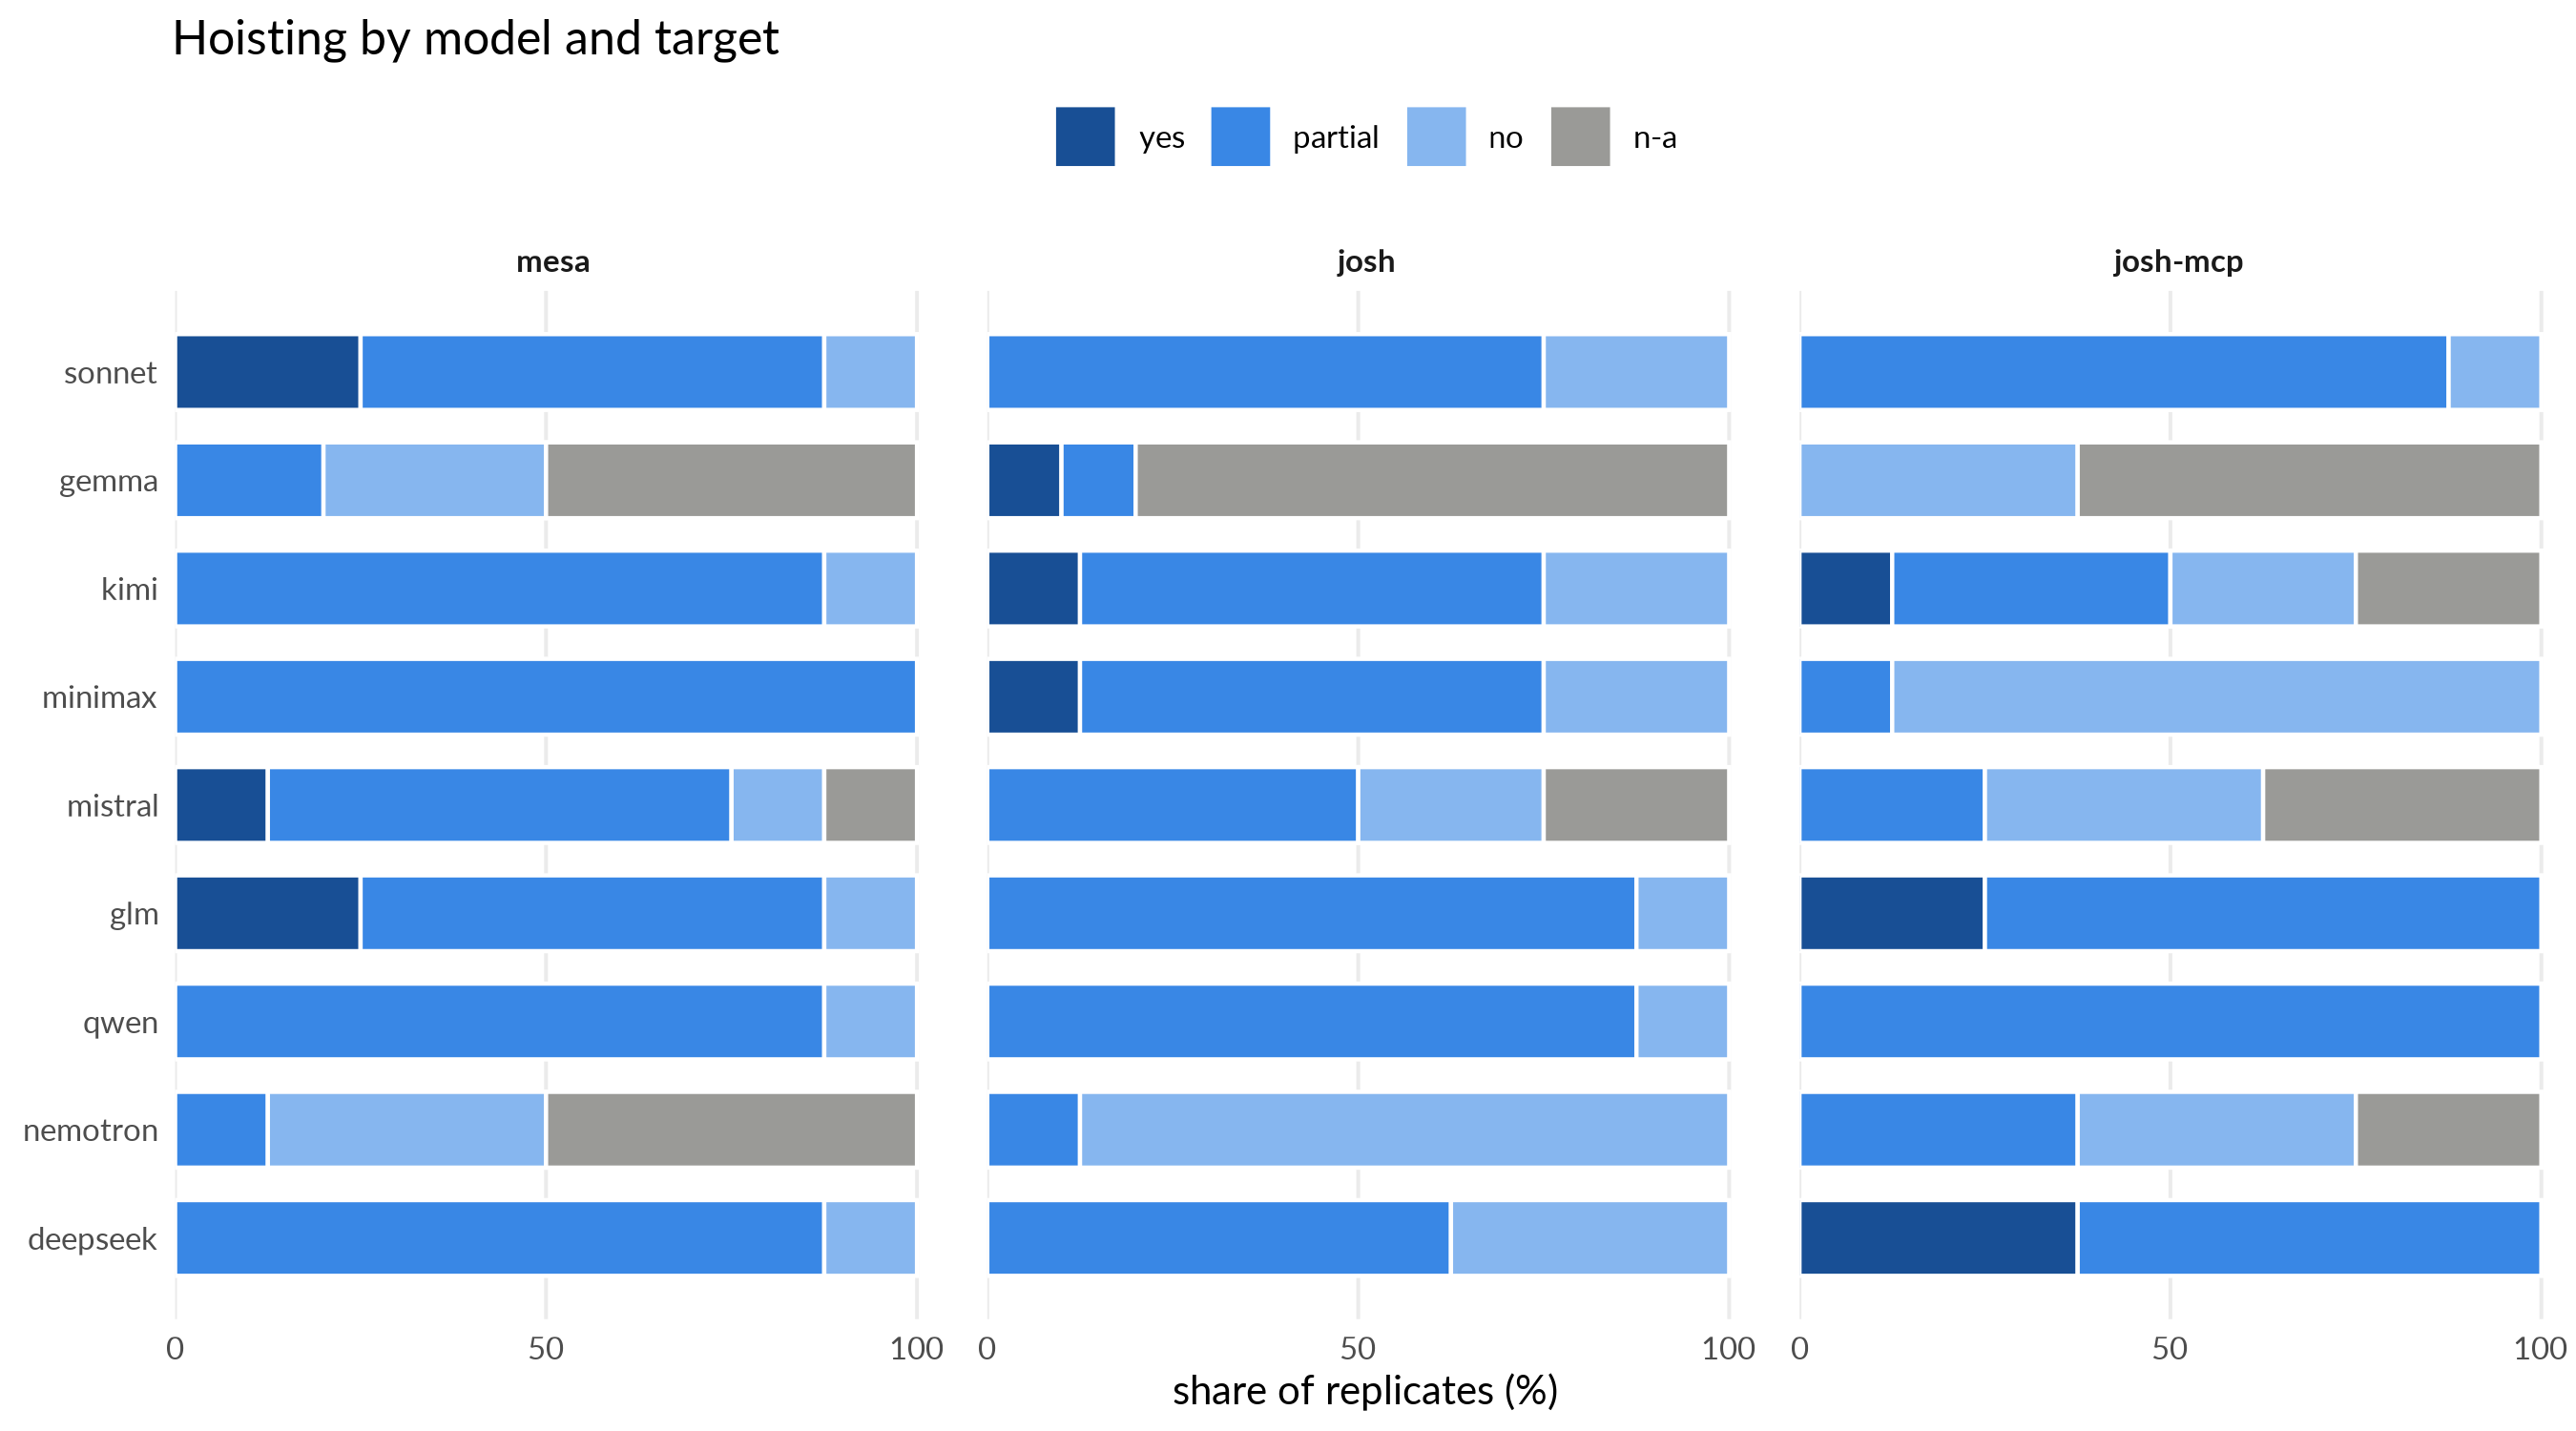

In [5]:
options(repr.plot.width = 9, repr.plot.height = 5)

# Same explicit geometry as the target chart — position_stack cannot be trusted
# to agree with the fill factor's order here either.
grid_bars <- hoist %>%
  count(model, target, answer, .drop = FALSE) %>%
  group_by(model, target) %>%
  arrange(answer, .by_group = TRUE) %>%
  mutate(total = sum(n),
         share = ifelse(total == 0, 0, n / total),
         xmax  = cumsum(share),
         xmin  = xmax - share) %>%
  ungroup() %>%
  filter(share > 0) %>%
  mutate(yi   = as.integer(factor(model, levels = rev(MODEL_ORDER))),
         ymin = yi - 0.35, ymax = yi + 0.35)

p_grid <- ggplot(grid_bars) +
  geom_rect(aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = answer),
            colour = "white", linewidth = 0.5) +
  facet_wrap(~ target, nrow = 1) +
  scale_fill_manual(values = ANSWER_COLORS, name = NULL, drop = FALSE) +
  # Bare numbers + the unit in the axis title: "100%" and "0%" collide at the
  # panel seams otherwise.
  scale_x_continuous(labels = c("0", "50", "100"), limits = c(0, 1),
                     breaks = c(0, 0.5, 1), expand = expansion(mult = c(0, 0.02))) +
  scale_y_continuous(breaks = seq_along(MODEL_ORDER), labels = rev(MODEL_ORDER),
                     expand = expansion(add = 0.4)) +
  labs(title = "Hoisting by model and target",
       x = "share of replicates (%)", y = NULL) +
  theme_hoist() +
  theme(panel.spacing = unit(14, "pt"))

p_grid
ggsave(file.path(OUT_DIR, "hoist_by_model.png"), p_grid,
       width = 9, height = 4.5, dpi = 300, bg = "white")
ggsave(file.path(OUT_DIR, "hoist_by_model.pdf"), p_grid, width = 9, height = 4.5)
options(repr.plot.width = 8, repr.plot.height = 3.2)

## What still runs per organism

`residual` is recorded independently of the verdict. The `yes` rows are the
interesting ones: a residual of `none` means the implementation fused the two
impacts into a single patch quantity (the expert Josh form), while `product of
hoisted patch scalars` means it left the final multiply in the organism (the
expert *Mesa* form, which wraps each climate variable separately).


In [6]:
hoist %>%
  mutate(residual = tolower(trimws(hoist_residual))) %>%
  count(answer, residual, sort = TRUE) %>%
  group_by(answer) %>%
  group_walk(~ {
    cat(sprintf("\n=== %s (%d) %s\n", .y$answer, sum(.x$n), strrep("=", 30)))
    print(as.data.frame(.x), row.names = FALSE)
  })


=== yes (14) ==============================
                         residual  n
 product of hoisted patch scalars 13
                             none  1

=== partial (123) ==============================
                                                           residual   n
                             temperature curve, precipitation curve 116
            temperature curve, precipitation curve, unit conversion   2
         temperature lookup, temperature curve, precipitation curve   2
 temperature climate lookup, temperature curve, precipitation curve   1
                                                  temperature curve   1
            unit conversion, temperature curve, precipitation curve   1

=== no (51) ==============================
                                                                residual  n
                  climate lookup, temperature curve, precipitation curve 25
                                                                    none 13
 climate lookup, u

In [7]:
# Mechanisms named for the cells that did something.
hoist %>%
  filter(answer %in% c("yes", "partial")) %>%
  mutate(mechanism = tolower(trimws(hoist_mechanism))) %>%
  count(answer, mechanism, sort = TRUE) %>%
  filter(n > 1) %>%
  as.data.frame() %>%
  print(row.names = FALSE)

  answer                               mechanism  n
 partial                patch climate attributes 14
 partial          patch-scope climate attributes 11
     yes                  patch-scope attributes  4
 partial          patch attribute climate lookup  4
 partial                        patch attributes  4
 partial     patch attributes for climate lookup  4
 partial                per-patch climate lookup  4
 partial        patch attribute (climate lookup)  3
 partial                   patch attribute hoist  3
 partial            patch attributes for climate  3
 partial patch attributes holding climate lookup  3
 partial             patch stores climate values  3
 partial              patch-level climate lookup  3
 partial              patch-scope climate fields  3
     yes                  patch agent precompute  2
     yes                   patch-scope attribute  2
 partial                         patch attribute  2
 partial      patch attribute for climate lookup  2
 partial    

## Every `yes`, in full

Few enough to read. These are the cells that carried the factoring all the way.


In [8]:
hoist %>%
  filter(answer == "yes") %>%
  arrange(target, model) %>%
  rowwise() %>%
  group_walk(~ {
    cat(sprintf("%-46s %s / %s\n", .x$run_id, .x$model, .x$target))
    cat(sprintf("   mechanism : %s\n", .x$hoist_mechanism))
    cat(sprintf("   residual  : %s\n", .x$hoist_residual))
    cat(sprintf("   evidence  : %s\n", .x$hoist_evidence))
    cat(strwrap(.x$hoist_justification, width = 96, prefix = "   ",
                initial = "   why       : "), sep = "\n")
    cat("\n")
  })

headline-stage1-20260601-sonnet-mesa-r0        sonnet / mesa
   mechanism : patch agent precompute
   residual  : product of hoisted patch scalars
   evidence  : simulate.py:PatchAgent.step
   why       : Each patch agent pulls its cell’s temperature/precipitation for the current
   timestep, evaluates both response curves once, and then the tree loop only multiplies those
   shared scalars with the per-tree stochastic term.

headline-stage1-20260601-sonnet-mesa-r4        sonnet / mesa
   mechanism : patch agent precompute
   residual  : product of hoisted patch scalars
   evidence  : simulation.py: PatchAgent.step
   why       : Each PatchAgent loads its climate values and evaluates the temperature and
   precipitation response curves once per year, then calls each tree’s grow() with those
   factors so trees only multiply the shared pct_t and pct_p with their noise.

headline-stage1-20260601-mistral-mesa-r1       mistral / mesa
   mechanism : patch precompute
   residual  : product o

## Reading the `no` bucket carefully

`no` is not one population. Two sub-groups fall inside it and are worth
separating before the count is quoted:

- **Degenerate** — the implementation never reads climate at all (the tree
  adds a constant), so there is no patch-invariant work to share. Scored `no`
  because a per-organism growth loop exists, but it says nothing about whether
  the agent could have hoisted; there was nothing to hoist.
- **Borderline** — the residual omits the climate lookup, implying the patch
  does hold the climate and only the curves repeat. By the rubric that is
  `partial`; the judge read the sharing as incidental rather than deliberate.
  Few enough to adjudicate by hand.


In [9]:
no_cells <- hoist %>%
  filter(answer == "no") %>%
  mutate(residual = tolower(trimws(hoist_residual)),
         kind = case_when(
           residual == "none"            ~ "degenerate (no climate read at all)",
           !grepl("lookup", residual)     ~ "borderline (lookup looks shared)",
           TRUE                           ~ "genuine no (lookup + curves per organism)"))

no_cells %>% count(kind, sort = TRUE) %>% as.data.frame() %>% print(row.names = FALSE)

cat("\n--- borderline, for hand adjudication ---\n")
no_cells %>%
  filter(grepl("^borderline", kind)) %>%
  group_walk(~ for (i in seq_len(nrow(.x))) {
    cat(sprintf("%s  [%s]\n", .x$run_id[i], .x$hoist_residual[i]))
    cat(strwrap(.x$hoist_justification[i], width = 96, prefix = "   "), sep = "\n")
  })

cat(sprintf("\nExcluding degenerate cells, 'fully hoisted' over real attempts: %s\n",
  hoist %>%
    filter(answer != "n-a",
           !(answer == "no" & tolower(trimws(hoist_residual)) == "none")) %>%
    summarise(s = percent(sum(answer == "yes") / n(), accuracy = 1)) %>% pull(s)))

                                      kind  n
 genuine no (lookup + curves per organism) 35
       degenerate (no climate read at all) 13
          borderline (lookup looks shared)  3



--- borderline, for hand adjudication ---


fill-202606032041-nemotron-josh-r0  [temperature curve, precipitation curve]
   Each tree iteration recomputes the temperature and precipitation response curves even though
   the patch’s temperature and precipitation are shared, so no climate-derived work is hoisted
   to patch scope.
headline-rerep-202606020525-gemma-mesa-r0  [temperature curve, precipitation curve]
   Every tree’s step locates its patch, reads the patch’s temperature and precipitation, and
   recomputes the temperature and precipitation response curves itself, so no climate-derived
   work is shared across the patch’s trees.
headline-stage1-20260601-nemotron-josh-r3  [temperature curve, precipitation curve]
   Each tree’s step re-derives percent_T and percent_P from the patch’s temperature and
   precipitation, with no patch-level caching or shared attribute, so the impact math is redone
   per organism per timestep.



Excluding degenerate cells, 'fully hoisted' over real attempts: 8%


## Does hoisting track with a working implementation?

Cross-tab against the headline pass definition (`substantive_conformance` AND
`did_run`) — a check that the answer measures code structure and not merely
which cells produced output at all.


In [10]:
hoist %>%
  filter(!is.na(passed)) %>%
  count(answer, passed, .drop = FALSE) %>%
  pivot_wider(names_from = passed, values_from = n, values_fill = 0,
              names_prefix = "passed_") %>%
  mutate(pass_rate = percent(passed_TRUE / (passed_TRUE + passed_FALSE), accuracy = 1)) %>%
  as.data.frame() %>%
  print(row.names = FALSE)

  answer passed_FALSE passed_TRUE pass_rate
     yes            1          13       93%
 partial           16         107       87%
      no           24          27       53%
     n-a           32           0        0%
